In [1]:
# Use Python 3.12.3

import pandas as pd
import numpy as np
import nfl_data_py as nfl
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# seasons = range(2006, 2024)     #Passing stats started in 2006
pbp_py = nfl.import_pbp_data([2023])

2023 done.
Downcasting floats.


In [3]:
len(pbp_py)

49665

<h2>Cleaning Data</h2>

In [27]:
#Select relevant features
game_situation = ["yardline_100", "quarter_seconds_remaining", "half_seconds_remaining", "game_seconds_remaining", "drive", "qtr", "down", "ydstogo", "score_differential"] 
offensive = ["offense_formation", "offense_personnel"]
defensive = ["defenders_in_box", "defense_personnel"]
play_type = ["play_type", "run_location", "run_gap", "pass_location", "pass_length"]

df = pbp_py[game_situation + offensive + defensive + play_type]

# Drop plays that aren't run or pass plays
df = df.dropna(subset=["play_type"]).reset_index(drop=True)
df = df.loc[df['play_type'].isin(['run', 'pass'])]
len(df)

35600

In [ ]:
df_combined = df.copy()

# Put together offensive play call
def combine_columns(row):
    if row['play_type'] == 'run':
        return f"{row['play_type']}_{row['run_location']}_{row['run_gap']}"
    elif row['play_type'] == 'pass':
        return f"{row['play_type']}_{row['pass_location']}_{row['pass_length']}"
    else:
        return None

#Combine the necessary parts of the offensive play together
df_combined['offensive_play'] = df_combined.apply(combine_columns, axis=1)

# Remove plays that result in successful defensive stop
df_combined = df_combined[~df_combined['offensive_play'].isin(['pass_None_None', 'run_None_None', 'run_right_None', 'run_middle_None', 'run_left_None'])]
len(df_combined)

30000

<h2>Crosstab Analysis</h2>

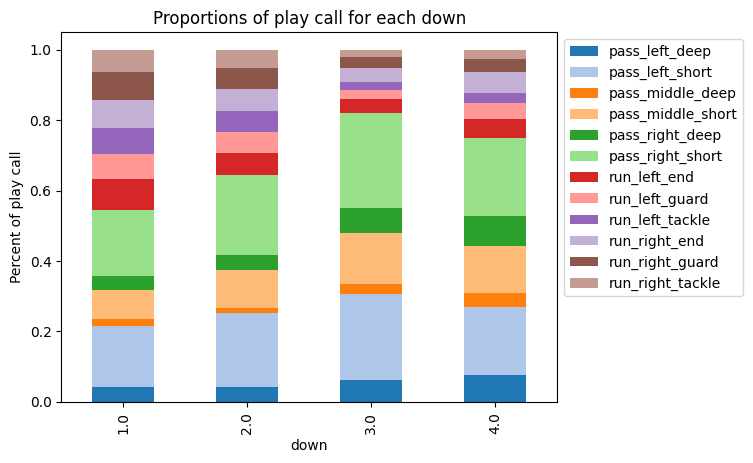

In [ ]:
custom_palette = sns.color_palette("tab20", 12)

#Analyzing play call for each down
pd.crosstab(df_combined['down'], df_combined['offensive_play'], normalize="index").plot(kind='bar', stacked=True, color=custom_palette)

plt.title("Proportions of play call for each down")
plt.xlabel("down")
plt.ylabel("Percent of play call")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

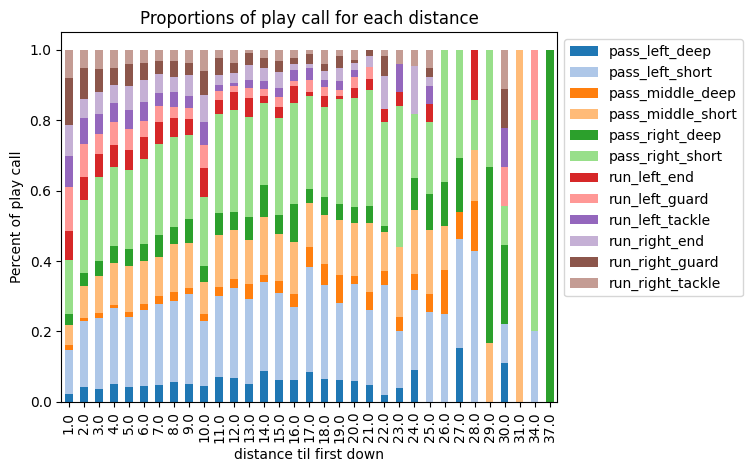

In [30]:
#Analyzing play call for each down
pd.crosstab(df_combined['ydstogo'], df_combined['offensive_play'], normalize="index").plot(kind='bar', stacked=True, color=custom_palette)

plt.title("Proportions of play call for each distance")
plt.xlabel("distance til first down")
plt.ylabel("Percent of play call")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

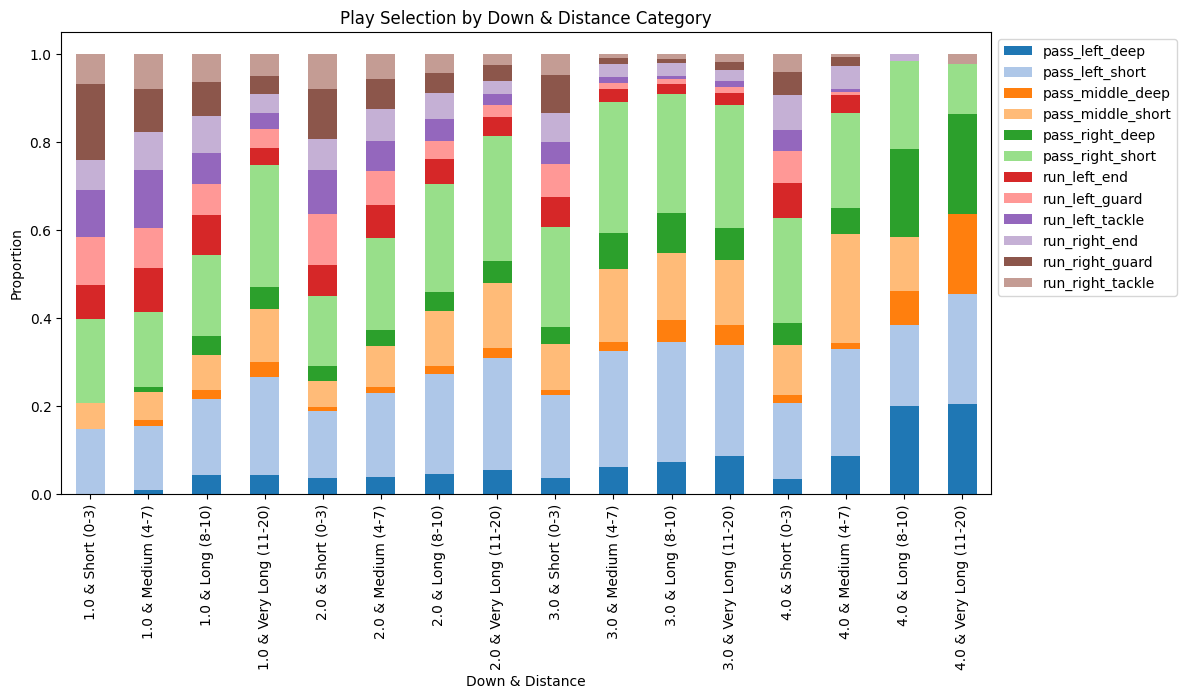

In [33]:
#Combining downs and distance together, graph is a bit messy
df_combined['distance_bin'] = pd.cut(df_combined['ydstogo'], bins=[0, 3, 7, 10, 20], labels=['Short (0-3)', 'Medium (4-7)', 'Long (8-10)', 'Very Long (11-20)'])
df_combined['distance_bin'][:10]
df_combined = df_combined.dropna(subset=['distance_bin'])
df_combined['down_distance'] = df_combined['down'].astype(str) + ' & ' + df_combined['distance_bin'].astype(str)

custom_order = ["1.0 & Short (0-3)", "1.0 & Medium (4-7)", "1.0 & Long (8-10)", "1.0 & Very Long (11-20)",
                "2.0 & Short (0-3)", "2.0 & Medium (4-7)", "2.0 & Long (8-10)", "2.0 & Very Long (11-20)",
                "3.0 & Short (0-3)", "3.0 & Medium (4-7)", "3.0 & Long (8-10)", "3.0 & Very Long (11-20)",
                "4.0 & Short (0-3)", "4.0 & Medium (4-7)", "4.0 & Long (8-10)", "4.0 & Very Long (11-20)"
                ]

pd.crosstab(df_combined['down_distance'], df_combined['offensive_play'], normalize='index').reindex(custom_order).plot(kind='bar', stacked=True, figsize=(12,6), color=custom_palette)
plt.title('Play Selection by Down & Distance Category')
plt.ylabel('Proportion')
plt.xlabel('Down & Distance')
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

<h2>Statistical Significance Tests</h2>

In [47]:
from scipy.stats import f_oneway

numerical_vars = game_situation

print("F-statistic:")
for i in numerical_vars:
    groups = [group[i].dropna() for name, group in df_combined.groupby('offensive_play')]
    f_stat, p_value = f_oneway(*groups)
    print(f"{i} = {round(f_stat, 3)}\n\tp-value = {p_value}")

F-statistic:
yardline_100 = 17.448
	p-value = 4.6495292426294033e-35
quarter_seconds_remaining = 16.944
	p-value = 6.3977994196775475e-34
half_seconds_remaining = 22.964
	p-value = 1.3098967242468072e-47
game_seconds_remaining = 6.657
	p-value = 3.0668145245852054e-11
drive = 5.045
	p-value = 6.398363070532884e-08
qtr = 3.675
	p-value = 3.049461354583924e-05
down = 124.882
	p-value = 2.2453012418361745e-281
ydstogo = 28.903
	p-value = 3.212821218195869e-61
score_differential = 49.51
	p-value = 1.0503276415574975e-108


In [44]:
table = pd.crosstab(df_combined["offense_formation"], df_combined['offensive_play'])
table = table.style.set_caption("Cross Tabulation: Offense Formation vs. Offensive Play")\
        .background_gradient(cmap="Blues")\
        .format(na_rep="–")

html = table.to_html()

with open("crosstab_table.html", "w") as f:
    f.write(html)

In [46]:
from scipy.stats import chi2_contingency
import pandas as pd

categorical_vars = offensive + defensive

print("Chi-Squared:")
for i in categorical_vars:
    table = pd.crosstab(df_combined[i], df_combined['offensive_play'])
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"{i} = {chi2}\n\tp-value: {p}")

Chi-Squared:
offense_formation = 5281.024429601799
	p-value: 0.0
offense_personnel = 2551.3180252322463
	p-value: 9.376317352771514e-220
defenders_in_box = 3355.6143294555445
	p-value: 0.0
defense_personnel = 2606.6442495084243
	p-value: 1.0477556941132738e-228


<h2>EPA Analysis</h2>

In [3]:
pbp_run = pbp_py.query('play_type == "run" & rusher_id.notnull()').reset_index()
pbp_run.groupby(["season"]).agg({"rushing_yards" : ["mean", "sum"]}) # simple breakdown
run_brkdwn = pbp_run.groupby(["season", "run_location", "run_gap"]).agg({"rushing_yards" : ["mean", "sum"], "epa": ["mean"]}) # breakdown of run location/gap

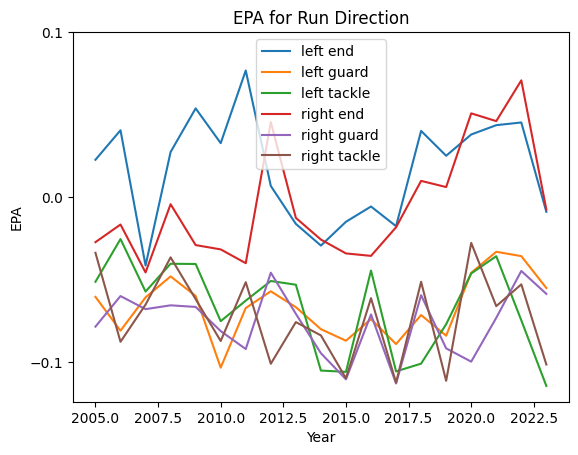

In [ ]:
run_gap = ["end", "guard", "tackle"]
run_side = ["left", "right"]

for j in run_side:
    for i in run_gap:
        run_direction = run_brkdwn.loc[(slice(None), j, i), :].reset_index()
        plt.plot(run_direction["season"], run_direction['epa'], label=f'{j} {i}')
f
plt.title("EPA for Run Direction")
plt.xlabel("Year")
plt.ylabel("EPA")
plt.yticks([-.1, 0, .1])
plt.legend()
plt.show()

In [5]:
pbp_pass = pbp_py.query('play_type == "pass" & passer_id.notnull()').reset_index()
pbp_pass.groupby(["season"]).agg({"passing_yards" : ["mean", "sum"]}) # simple breakdown
pass_brkdwn = pbp_pass.groupby(["season", "pass_location", "pass_length"]).agg({"passing_yards" : ["mean", "sum"], "epa" : ["mean"]})

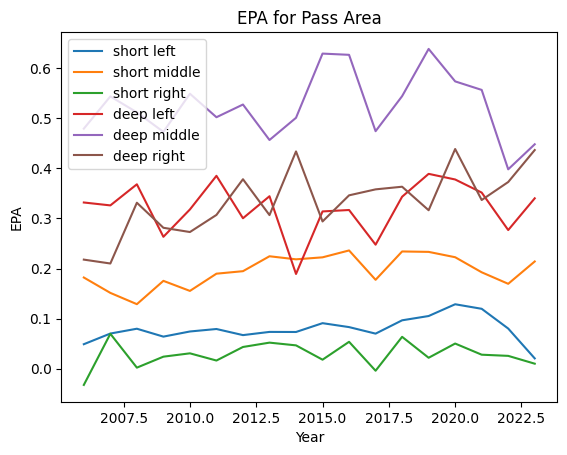

In [6]:
pass_location = ["left", "middle", "right"]
pass_length = ["short", "deep"]

for j in pass_length:
    for i in pass_location:
        pass_area = pass_brkdwn.loc[(slice(None), i, j), :].reset_index()
        plt.plot(pass_area["season"], pass_area['epa'], label=f'{j} {i}')

plt.title("EPA for Pass Area")
plt.xlabel("Year")
plt.ylabel("EPA")
plt.legend()
plt.show()

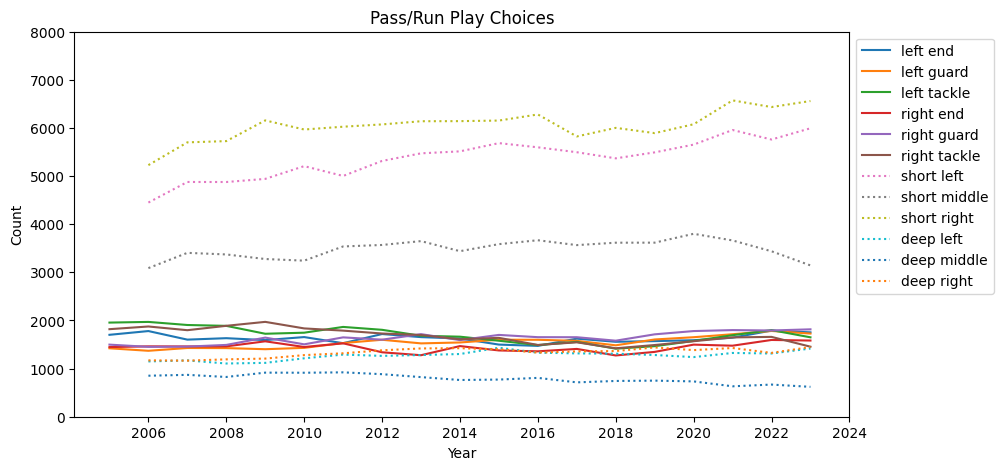

In [33]:
run_counts = pbp_run.groupby(["season", "run_location", "run_gap"]).agg({"index": ["count"]})
pass_counts = pbp_pass.groupby(["season", "pass_location", "pass_length"]).agg({"index": ["count"]})

run_gap = ["end", "guard", "tackle"]
run_side = ["left", "right"]

plt.figure(figsize=(10, 5))

for j in run_side:
    for i in run_gap:
        run_direction = run_counts.loc[(slice(None), j, i), :].reset_index()
        plt.plot(run_direction["season"], run_direction['index'], label=f'{j} {i}')

pass_location = ["left", "middle", "right"]
pass_length = ["short", "deep"]

for j in pass_length:
    for i in pass_location:
        pass_area = pass_counts.loc[(slice(None), i, j), :].reset_index()
        plt.plot(pass_area["season"], pass_area['index'], linestyle=":",label=f'{j} {i}')
    
plt.title("Pass/Run Play Choices")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(np.arange(2006, 2025, 2))
plt.yticks(np.linspace(0, 8000, 9))
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.show()